# Plots for Report


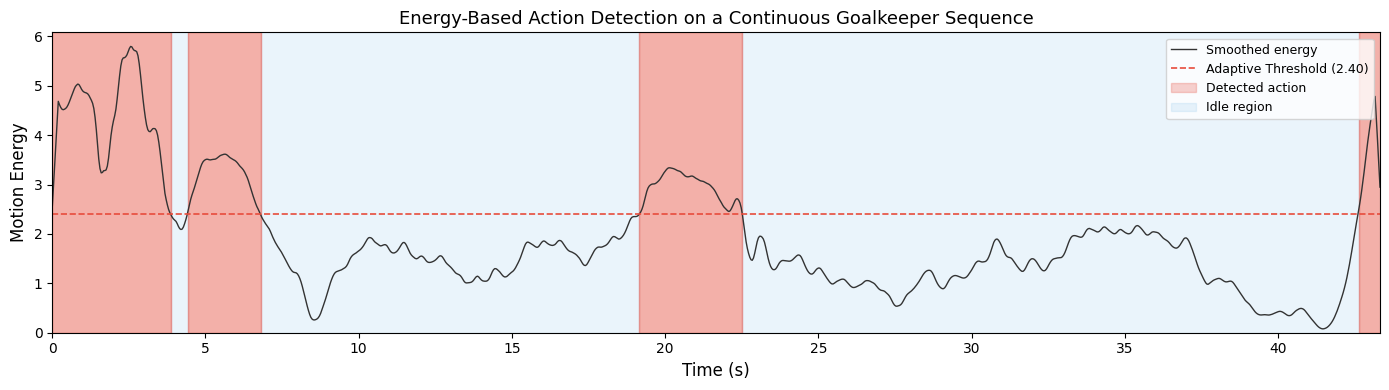

Sequence: 1084 frames (43.4s), 4 actions detected, threshold=2.40
Number of gap-filled intervals: 0
Any below-threshold inside action? False


In [11]:
import sys, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from preprocessing.processing_utils import (
    compute_motion_energy, detect_activity_segments, align_to_goal, NATIVE_JOINTS
)

# ── Load a real continuous sequence from filtered data ───────────────────────
filtered_path = Path("../data/filtered/2036161_gk_joints.json")
with open(filtered_path) as f:
    match_data = json.load(f)

gk_id = list(match_data.keys())[0]          # first goalkeeper
sequences = match_data[gk_id]               # list of continuous sequences

# Pick sequence index 1 (1084 frames, ~43s, has multiple actions)
raw_seq = sequences[1]

# Align to goal and convert to numpy array (T, 29, 3)
aligned = [align_to_goal(frame) for frame in raw_seq]
sequence = np.array([[f[j] for j in NATIVE_JOINTS] for f in aligned])

fps = 25

# ── Compute energy & run detection ──────────────────────────────────────────
energy = compute_motion_energy(sequence)

# Smoothed energy (same as in detect_activity_segments)
window_size = int(0.4 * fps)
smoothed = np.convolve(energy, np.ones(window_size) / window_size, mode='same')

# Threshold computation (mirrors processing_utils logic)
baseline_median = np.median(smoothed)
mad = np.median(np.abs(smoothed - baseline_median))
sigma = max(mad * 1.4826, 0.2)
adaptive_thresh = baseline_median + 1.0 * sigma
threshold = max(adaptive_thresh, 1.65)

action_segs, idle_segs = detect_activity_segments(sequence, fps=fps)

# --- Identify gap-filled frames inside action segments -----------------------
# Raw above-threshold mask
is_active_raw = smoothed > threshold

T = len(smoothed)
action_mask = np.zeros(T, dtype=bool)
for s, e in action_segs:
    action_mask[s:e] = True

# Frames that are inside an action segment but below threshold
gap_filled_mask = action_mask & ~is_active_raw

# Convert gap_filled_mask into contiguous (start, end) intervals
gap_intervals = []
idx = np.where(gap_filled_mask)[0]
if len(idx) > 0:
    start = idx[0]
    prev = idx[0]
    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            gap_intervals.append((start, prev + 1))
            start = k
            prev = k
    gap_intervals.append((start, prev + 1))

# ── Plot ────────────────────────────────────────────────────────────────────
time = np.arange(len(smoothed)) / fps

fig, ax = plt.subplots(figsize=(14, 4))

# Energy curve
ax.plot(time, smoothed, color="#333333", linewidth=1.0, label="Smoothed energy")

# Threshold line
ax.axhline(threshold, color="#E74C3C", linestyle="--", linewidth=1.2,
           label=f"Threshold ({threshold:.2f})")

# Detected action segments
for i, (s, e) in enumerate(action_segs):
    ax.axvspan(s / fps, e / fps, alpha=0.25, color="#E74C3C", zorder=1,
               label="Detected action" if i == 0 else None)

# Detected idle segments (optional subtle shading)
for i, (s, e) in enumerate(idle_segs):
    ax.axvspan(s / fps, e / fps, alpha=0.10, color="#3498DB", zorder=0,
               label="Idle region" if i == 0 else None)

# Detected action segments (whole merged segments)
for i, (s, e) in enumerate(action_segs):
    ax.axvspan(s / fps, e / fps, alpha=0.25, color="#E74C3C", zorder=1,
               label="Detected action" if i == 0 else None)

# Gap-filled parts: inside actions but below threshold
for i, (s, e) in enumerate(gap_intervals):
    ax.axvspan(s / fps, e / fps, alpha=0.35, color="#F1C40F", zorder=2,
               label="Gap-filled (below threshold)" if i == 0 else None)
               
# Labels & legend
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Motion Energy", fontsize=12)
ax.set_title("Energy-Based Action Detection on a Continuous Goalkeeper Sequence", fontsize=13)

detect_patch = mpatches.Patch(color="#E74C3C", alpha=0.25, label="Detected action")
idle_patch = mpatches.Patch(color="#3498DB", alpha=0.10, label="Idle region")
ax.legend(handles=[
    plt.Line2D([0], [0], color="#333333", lw=1.0, label="Smoothed energy"),
    plt.Line2D([0], [0], color="#E74C3C", ls="--", lw=1.2, label=f"Adaptive Threshold ({threshold:.2f})"),
    detect_patch, idle_patch
], loc="upper right", fontsize=9)

ax.set_xlim(0, time[-1])
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig("../data/energy_profile.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sequence: {len(sequence)} frames ({len(sequence)/fps:.1f}s), "
      f"{len(action_segs)} actions detected, threshold={threshold:.2f}")

print("Number of gap-filled intervals:", len(gap_intervals))
print("Any below-threshold inside action?", np.any((smoothed < threshold) & action_mask))

In [7]:
sys.path.append(str(Path.cwd().parent / "animations"))
from visualize_tensor_sample import animate_skeleton, BONES_NATIVE

# `sequence` is already (T=1084, V=29, C=3) from the cell above, aligned & in native Z-up coords
# No axis swap needed for native skeleton (Z is already up)
output_path = "../data/videos/continuous_sequence_2036161.mp4"
animate_skeleton(sequence, output_path, bones=BONES_NATIVE, fps=25, swap_axis=False)

NameError: name 'Path' is not defined

# Parameter Count

In [8]:
import sys
import os
import torch
from pathlib import Path

# Add CrosSCLR to path
sys.path.insert(0, os.path.abspath('../models/CrosSCLR'))

# Import ST-GCN and CrosSCLR directly
from net.st_gcn import Model as ST_GCN
from net.crossclr_3views import CrosSCLR

model_args_native = {
    'base_encoder': ST_GCN,  # Pass class directly instead of string
    'pretrain': True,
    'feature_dim': 128,
    'queue_size': 16384,
    'momentum': 0.999,
    'Temperature': 0.07,
    'mlp': True,
    'in_channels': 3,
    'hidden_channels': 16,
    'hidden_dim': 256,
    'num_class': 60,
    'dropout': 0.5,
    'graph_args': {'layout': 'native', 'strategy': 'spatial'},
    'edge_importance_weighting': True,
}

model_native = CrosSCLR(**model_args_native)

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model_native)

print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters:    {total_params - trainable_params:,}")

ImportError: cannot import name 'import_class' from 'torchlight' (unknown location)